# main notebook  

In [18]:
# Required packages for the project
%pip install pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import pandas as pd
import json

# Load your raw env sensor data
df_raw = pd.read_csv("data/raw/5EnvSensor_MayToDec2024_180kRows.csv")

print(df_raw.shape)
df_raw.head()

(179447, 8)


,id,sensorid,devicetype,jsondata,status,processing_errors,createdate,processdate
0,2,6012002000241,env,"[{""values"": [{""time"": 1702273965, ""value"": 4.1...",Processed,NaN,2024-02-29 03:11:58.210358+11,2024-02-29 03:11:58.210358+11
1,4,6012002000241,env,"[{""values"": [{""time"": 1702273965, ""value"": 4.1...",Processed,NaN,2024-02-29 17:09:08.833822+11,2024-02-29 17:09:08.833822+11
2,5,6012002000326,env,"[{""values"": [{""time"": 1702270857, ""value"": 4.1...",Processed,NaN,2024-02-29 17:09:12.444245+11,2024-02-29 17:09:12.444245+11
3,16,6012002000777,env,"[{""values"": [{""time"": 1683326565, ""value"": 4.1...",Processed,NaN,2024-02-29 17:10:24.443407+11,2024-02-29 17:10:24.443407+11
4,24,6012002000869,env,"[{""values"": [{""time"": 1709186696, ""value"": 4.1...",Processed,NaN,2024-02-29 17:11:11.348578+11,2024-02-29 17:11:11.348578+11


In [20]:
# 1. Re-run the updated function definition (the one with device_time added)
def parse_jsondata(row):
    readings = json.loads(row['jsondata'])
    parsed = {
        'sensorid': row['sensorid'],
        'timestamp': row['createdate'],
        'device_time': None
    }
    for item in readings:
        var_name = item['variable']['name']
        values_list = item.get('values', [])
        if not values_list:
            continue
        value_entry = values_list[0]
        parsed[var_name] = value_entry.get('value')
        parsed['device_time'] = value_entry.get('time')
    return parsed

#Rebuild df_env from df_raw using the updated function
parsed_rows = df_raw.apply(parse_jsondata, axis=1)
df_env = pd.DataFrame(list(parsed_rows))


In [21]:
#checking each variable to see how many had missing values
df_env.isna().sum()


sensorid                                 0
timestamp                                0
device_time                              0
Battery                                  0
Carbon dioxide                           0
Humidity                                 0
Formaldehyde                        113380
Pressure                                 0
Temperature                              0
Light Volatile Organic Compounds     29566
Particulate matter 1                  1709
Particulate matter 4                  1709
Particulate matter 2.5                1709
Particulate matter 10                 1709
dtype: int64

In [22]:
#checking if the duplicated data exist for a particular sensor over time
duplicates = df_env.duplicated(subset=['sensorid', 'device_time'], keep=False)
print(f"Duplicate rows: {duplicates.sum()}")
#checking duplicated columns if every entry is fully identical over time
compare_cols = [c for c in df_env.columns if c != 'timestamp']

key_dupes = df_env[df_env.duplicated(subset=['sensorid', 'device_time'], keep=False)]
fully_identical = key_dupes.duplicated(subset=compare_cols, keep=False).sum()

print(f"Of {len(key_dupes)} rows sharing sensorid+device_time, {fully_identical} are identical in every other column")

Duplicate rows: 136996
Of 136996 rows sharing sensorid+device_time, 136996 are identical in every other column


In [23]:
# How many rows share each (sensorid, device_time) pair?
group_sizes = df_env.groupby(['sensorid', 'device_time']).size()
print(group_sizes.value_counts().sort_index())

# Convert once, properly, handling the mixed +11/+10 offsets
df_env['timestamp'] = pd.to_datetime(df_env['timestamp'], utc=True)

# Now this is simpler and won't error
dupe_groups = df_env[df_env.duplicated(subset=['sensorid', 'device_time'], keep=False)]
time_spread = dupe_groups.groupby(['sensorid', 'device_time'])['timestamp'].agg(lambda x: x.max() - x.min())
print(time_spread.describe())

1        42451
2          299
3           37
4           26
5            9
6            2
7            4
8            2
9            1
10           1
11           1
16           1
19           1
22           1
25           1
10926        1
15431        1
21363        1
29342        2
29566        1
Name: count, dtype: int64
count                         392
mean       2 days 15:56:08.012893
std       22 days 10:25:49.077020
min        0 days 00:00:02.597510
25%        0 days 00:08:23.510879
50%        0 days 00:10:37.513971
75%        0 days 00:10:47.792948
max      227 days 03:06:27.015886
Name: timestamp, dtype: object


In [24]:
# Check Battery specifically within one of the big duplicate groups
one_group = df_env[(df_env['sensorid'] == 6012002000241)]
one_group['Battery'].value_counts().head(10)

# Check Battery value diversity within each sensor's duplicate group
for sid, dtime in dupe_groups.groupby(['sensorid', 'device_time']).size().sort_values(ascending=False).head(6).index:
    group = df_env[(df_env['sensorid'] == sid) & (df_env['device_time'] == dtime)]
    print(f"Sensor {sid}, device_time {dtime}: {len(group)} rows, {group['Battery'].nunique()} unique Battery values")

# Keep a copy with duplicates intact, for demonstrating the data quality issue
df_env_with_dupes = df_env.copy()

# Now clean as normal — this is what you'll use for modelling going forward
df_env = df_env.drop_duplicates(subset=['sensorid', 'device_time'], keep='first').reset_index(drop=True)
print(df_env.shape)


Sensor 6012002000241, device_time 1747660084: 29566 rows, 1 unique Battery values
Sensor 6012002000241, device_time 1702273965: 29342 rows, 1 unique Battery values
Sensor 6012002000326, device_time 1702270857: 29342 rows, 1 unique Battery values
Sensor 6012002000227, device_time 1702271273: 21363 rows, 1 unique Battery values
Sensor 6012002000869, device_time 1718300744: 15431 rows, 1 unique Battery values
Sensor 6012002000777, device_time 1683326565: 10926 rows, 1 unique Battery values
(42843, 14)


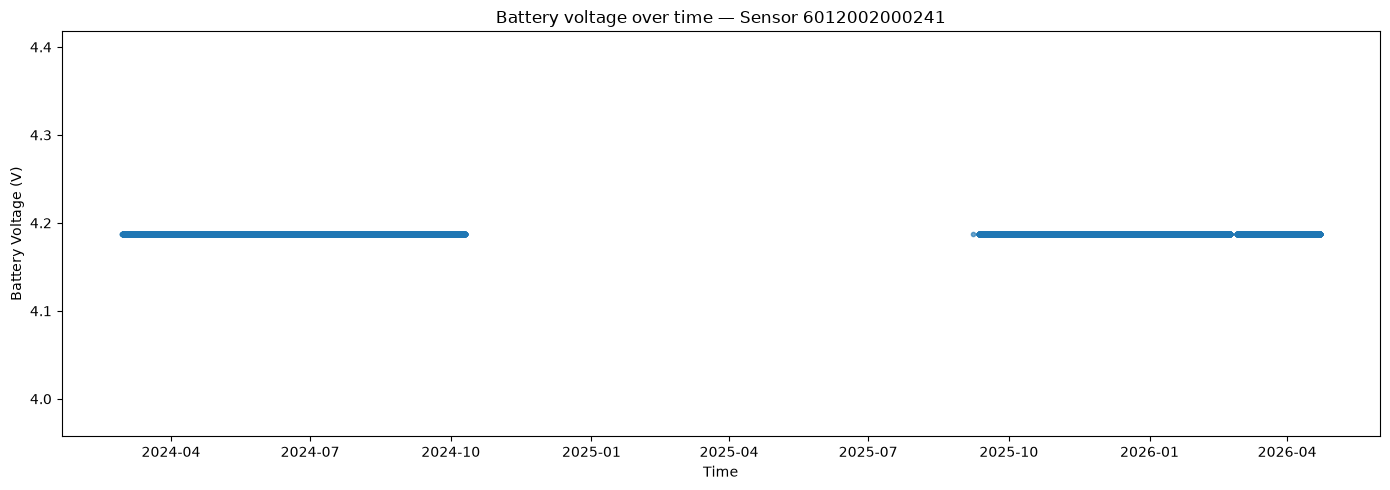

In [25]:
import matplotlib.pyplot as plt

# Pick one of the heavily-duplicated sensors to show clearly
sensor_id = 6012002000241

sensor_data = df_env_with_dupes[df_env_with_dupes['sensorid'] == sensor_id].sort_values('timestamp')

plt.figure(figsize=(14, 5))
plt.plot(sensor_data['timestamp'], sensor_data['Battery'], marker='.', linestyle='none', alpha=0.4)
plt.xlabel('Time')
plt.ylabel('Battery Voltage (V)')
plt.title(f'Battery voltage over time — Sensor {sensor_id}')
plt.tight_layout()
plt.show()


2024-02-28 16:11:58.210358+00:00 2024-10-10 04:55:45.402148+00:00
224 days 12:43:47.191790


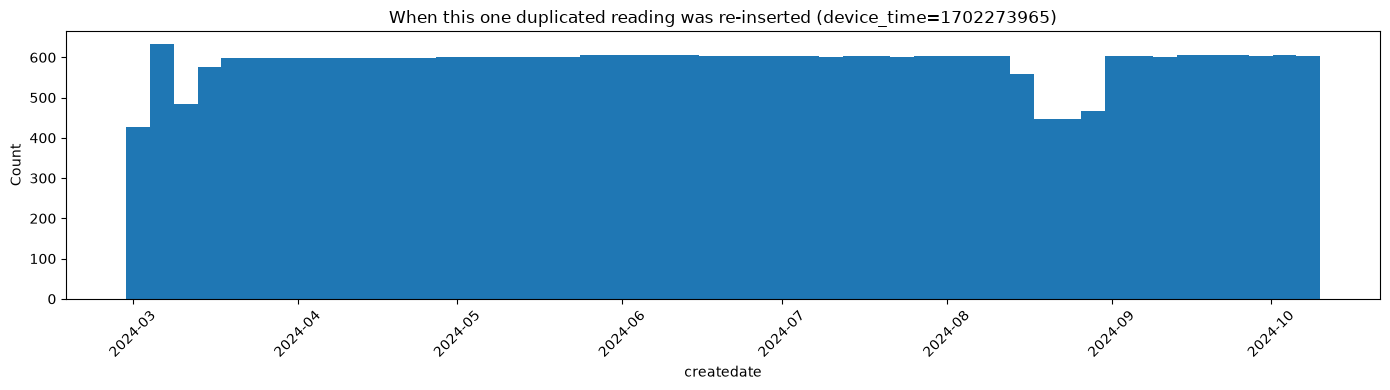

29342
int64
device_time
1747660084    29566
1702273965    29342
Name: count, dtype: int64


In [26]:
# Look at just one of the two mega-duplicate-groups for this sensor
group_data = df_env_with_dupes[
    (df_env_with_dupes['sensorid'] == sensor_id) & 
    (df_env_with_dupes['device_time'] == 1702273965)  # one of the two device_times you found
]

print(group_data['timestamp'].min(), group_data['timestamp'].max())
print(group_data['timestamp'].max() - group_data['timestamp'].min())

plt.figure(figsize=(14, 4))
plt.hist(group_data['timestamp'], bins=50)
plt.xlabel('createdate')
plt.ylabel('Count')
plt.title(f'When this one duplicated reading was re-inserted (device_time={1702273965})')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(len(group_data))
print(df_env_with_dupes['device_time'].dtype)
print(df_env_with_dupes[df_env_with_dupes['sensorid'] == sensor_id]['device_time'].value_counts().head())

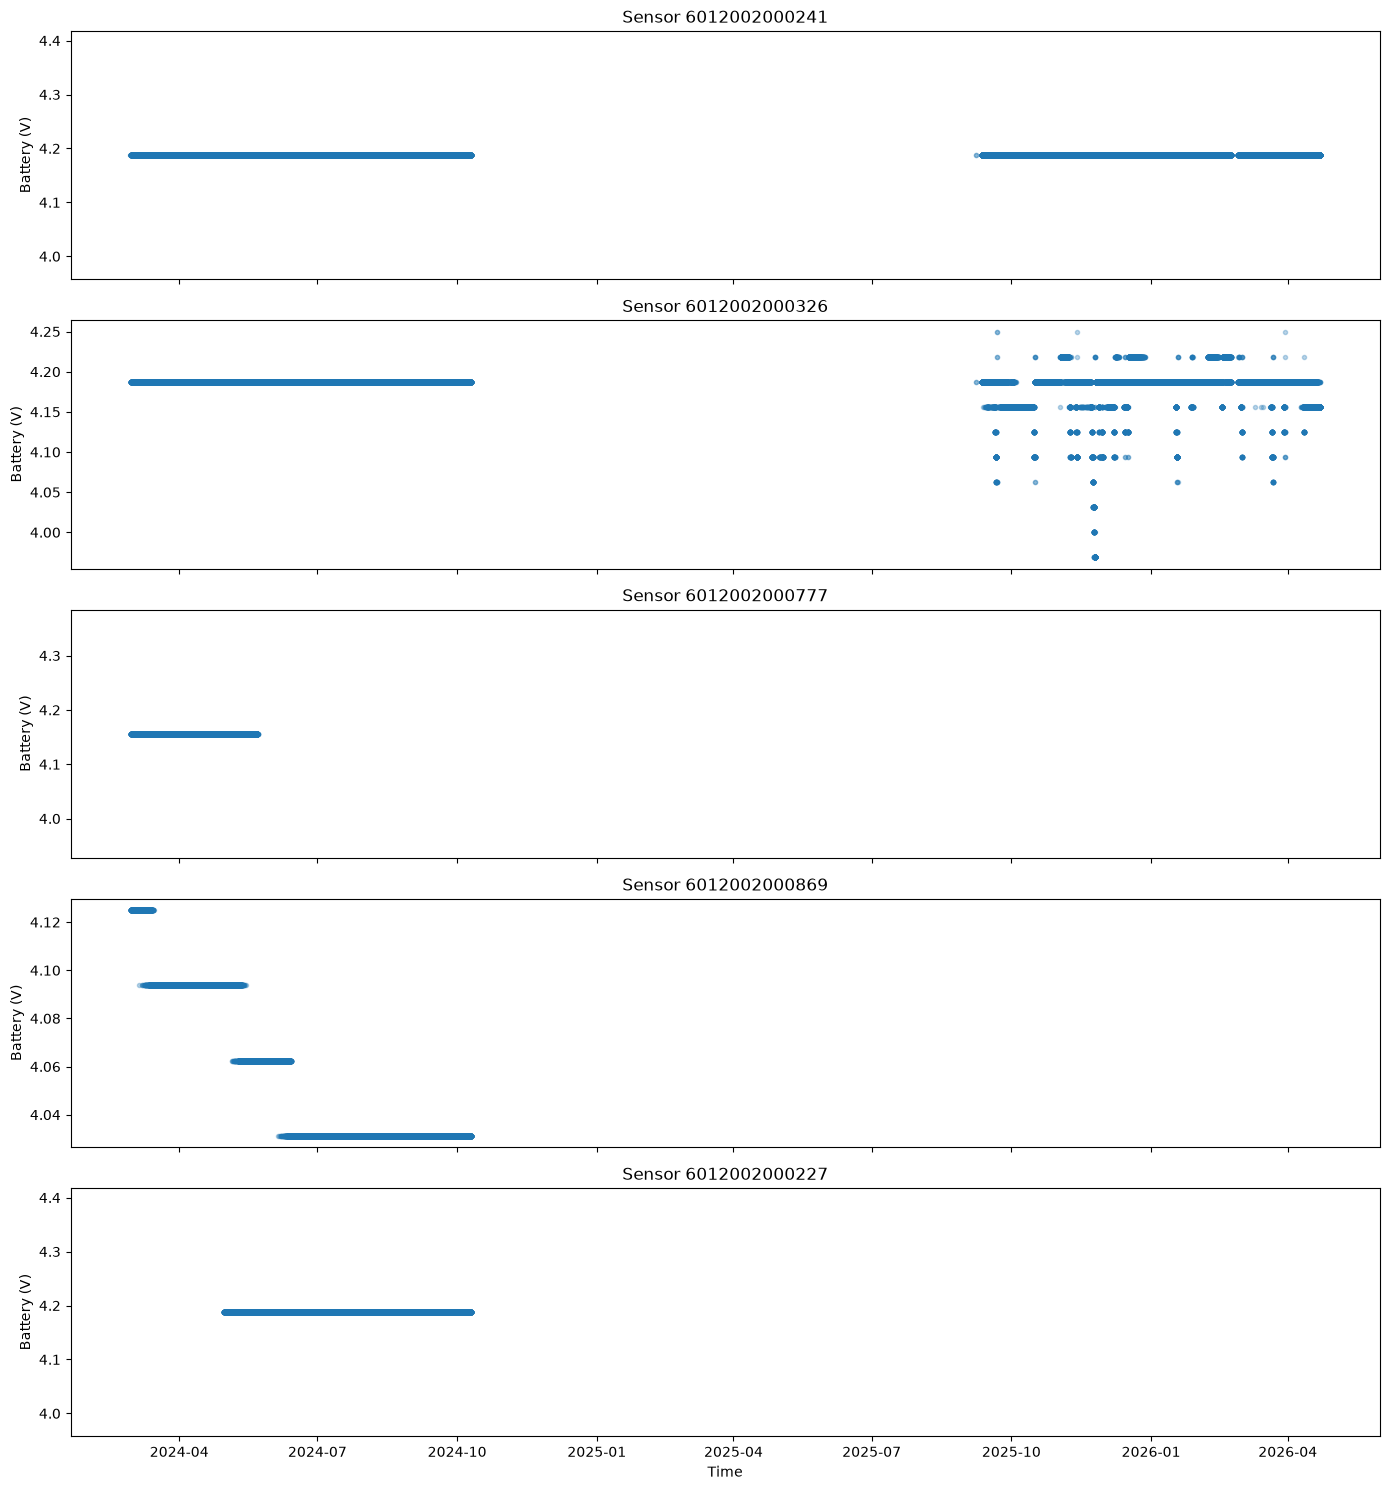

In [27]:
sensors = df_env_with_dupes['sensorid'].unique()
fig, axes = plt.subplots(len(sensors), 1, figsize=(14, 3 * len(sensors)), sharex=True)

for ax, sid in zip(axes, sensors):
    sensor_data = df_env_with_dupes[df_env_with_dupes['sensorid'] == sid].sort_values('timestamp')
    ax.plot(sensor_data['timestamp'], sensor_data['Battery'], marker='.', linestyle='none', alpha=0.3)
    ax.set_title(f'Sensor {sid}')
    ax.set_ylabel('Battery (V)')

plt.xlabel('Time')
plt.tight_layout()
plt.show()

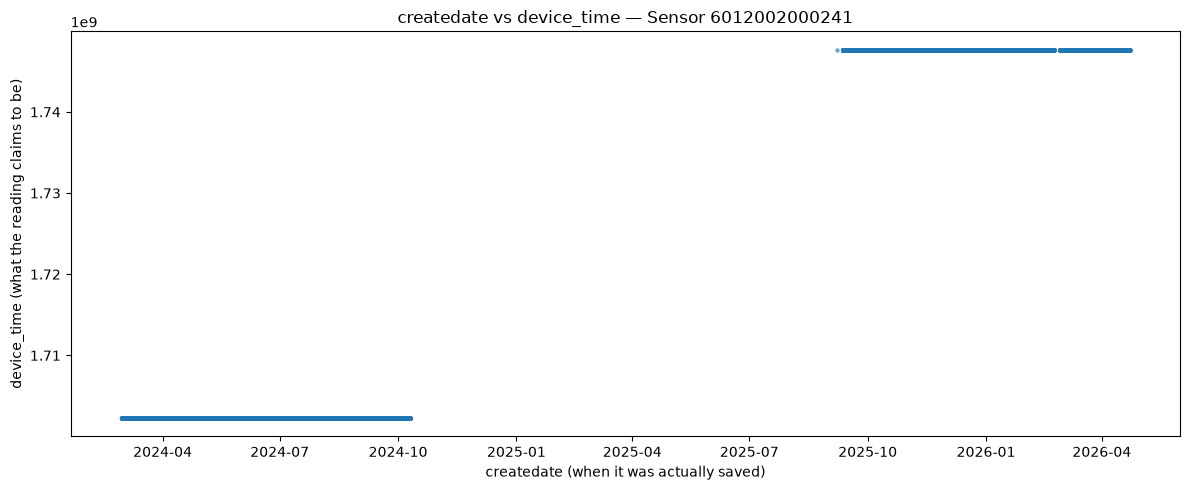

In [28]:
one_sensor = df_env_with_dupes[df_env_with_dupes['sensorid'] == sensor_id]

plt.figure(figsize=(12, 5))
plt.scatter(one_sensor['timestamp'], one_sensor['device_time'], alpha=0.3, s=5)
plt.xlabel('createdate (when it was actually saved)')
plt.ylabel('device_time (what the reading claims to be)')
plt.title(f'createdate vs device_time — Sensor {sensor_id}')
plt.tight_layout()
plt.show()

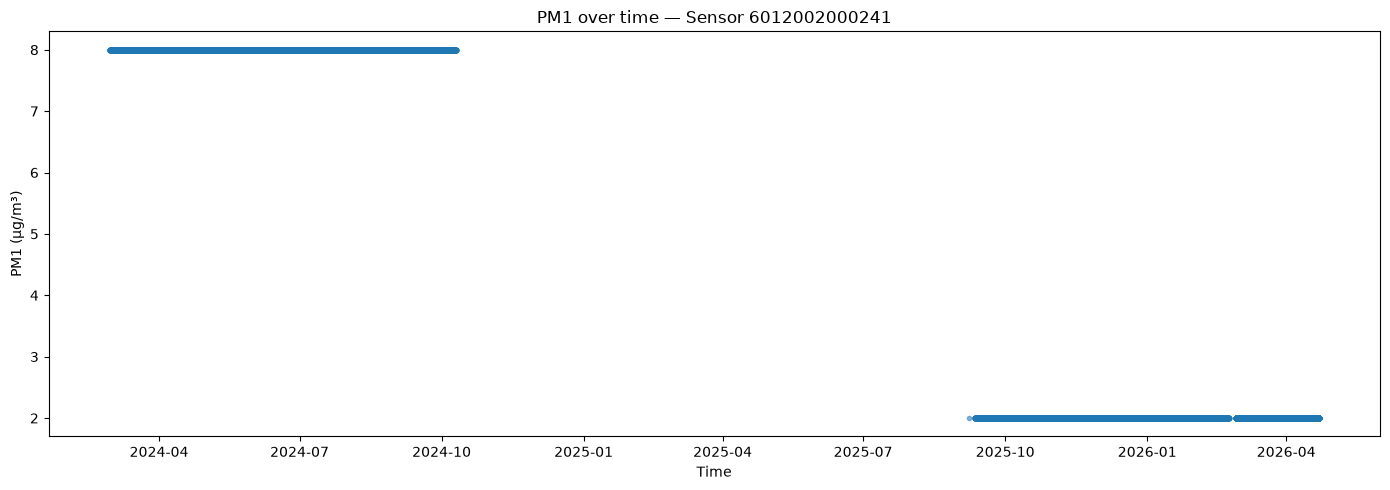

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(one_sensor['timestamp'], one_sensor['Particulate matter 1'], marker='.', linestyle='none', alpha=0.3)
plt.xlabel('Time')
plt.ylabel('PM1 (µg/m³)')
plt.title(f'PM1 over time — Sensor {sensor_id}')
plt.tight_layout()
plt.show()

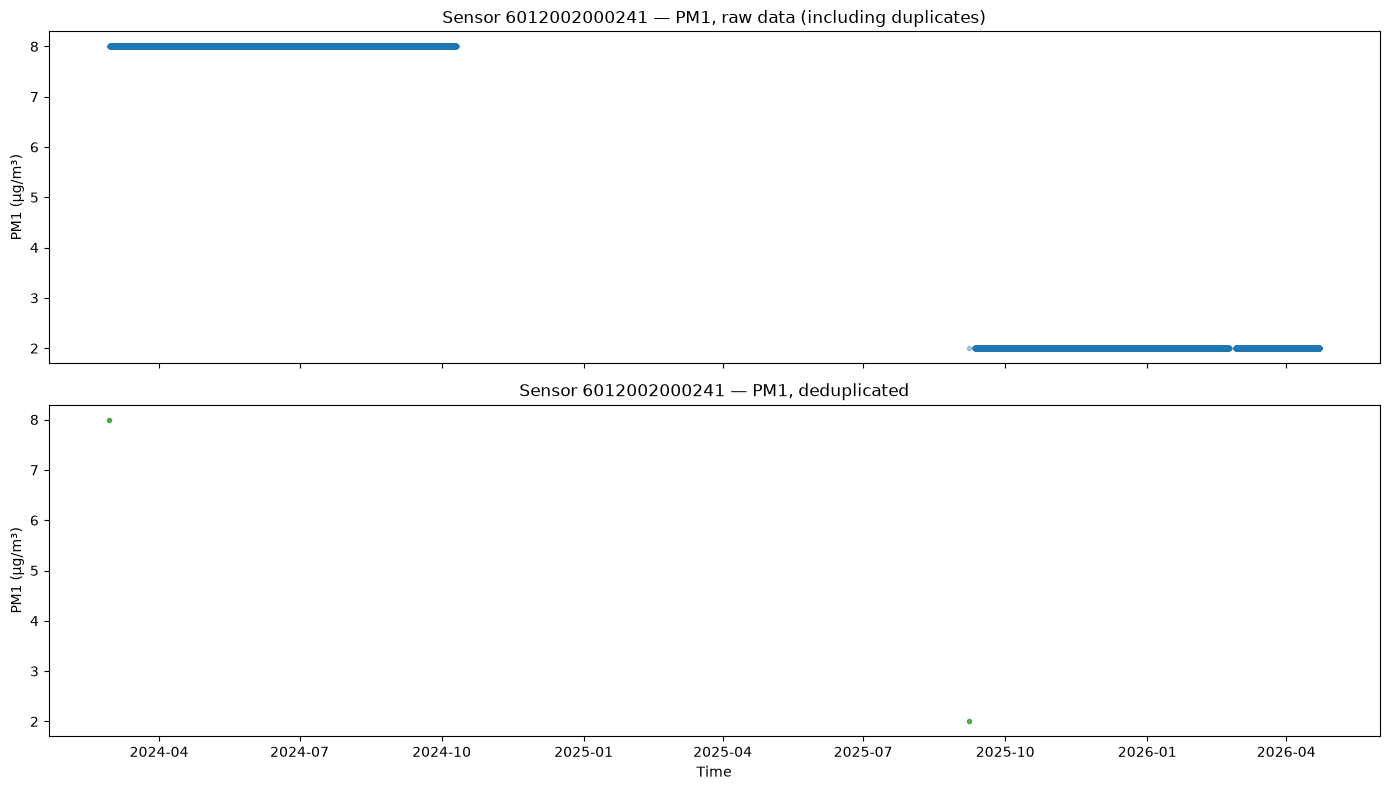

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: full data including duplicates — flat bands
axes[0].plot(one_sensor['timestamp'], one_sensor['Particulate matter 1'], marker='.', linestyle='none', alpha=0.2)
axes[0].set_title(f'Sensor {sensor_id} — PM1, raw data (including duplicates)')
axes[0].set_ylabel('PM1 (µg/m³)')

# Bottom: deduplicated data — should show genuine fluctuation
clean_sensor = df_env[df_env['sensorid'] == sensor_id].sort_values('timestamp')
axes[1].plot(clean_sensor['timestamp'], clean_sensor['Particulate matter 1'], marker='.', linestyle='none', alpha=0.6, color='green')
axes[1].set_title(f'Sensor {sensor_id} — PM1, deduplicated')
axes[1].set_ylabel('PM1 (µg/m³)')

plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [31]:
dupe_group_std = one_group['Particulate matter 1'].std()
clean_std = clean_sensor['Particulate matter 1'].std()
print(f"Std within one duplicate group: {dupe_group_std}")
print(f"Std across genuinely distinct readings: {clean_std}")

Std within one duplicate group: 3.000003774535628
Std across genuinely distinct readings: 4.242640687119285


In [32]:
# Build a reliability summary table across every sensor
summary_rows = []

for sid in df_env_with_dupes['sensorid'].unique():
    sensor_data = df_env_with_dupes[df_env_with_dupes['sensorid'] == sid]
    total_rows = len(sensor_data)
    distinct_readings = sensor_data.drop_duplicates(subset=['sensorid', 'device_time']).shape[0]
    pct_real = round(distinct_readings / total_rows * 100, 1)
    
    summary_rows.append({
        'sensorid': sid,
        'total_rows': total_rows,
        'distinct_readings': distinct_readings,
        'pct_real_data': pct_real,
        'unique_co2_values': sensor_data['Carbon dioxide'].nunique(),
        'unique_pm1_values': sensor_data['Particulate matter 1'].nunique(),
    })

reliability_summary = pd.DataFrame(summary_rows).sort_values('pct_real_data')
print(reliability_summary)

        sensorid  total_rows  distinct_readings  pct_real_data  \
0  6012002000241       58908                  2            0.0   
2  6012002000777       10926                  1            0.0   
4  6012002000227       21363                  1            0.0   
3  6012002000869       29341              13800           47.0   
1  6012002000326       58909              29039           49.3   

   unique_co2_values  unique_pm1_values  
0                  2                  2  
2                  1                  1  
4                  1                  1  
3                222                 68  
1                245                 21  
